mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
--- Logistic Regression ---
Accuracy: 0.956140350877193
Precision: 0.9487179487179487
Re

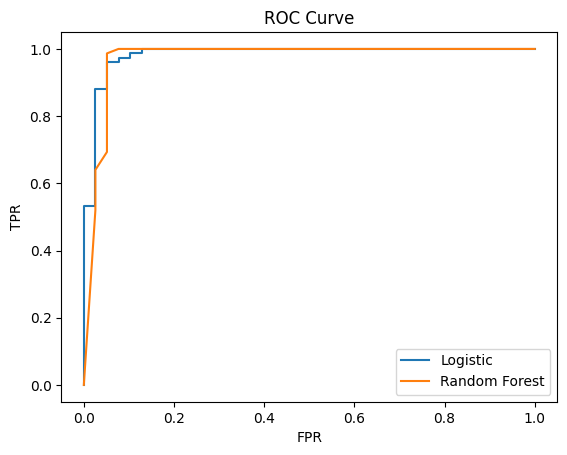

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 3. Preprocessing
print(df.isnull().sum())  # check missing

X = df.drop('target', axis=1)
y = df['target']

# 4. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 5. Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# 6. Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

# 7. Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_test, pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))
    print("ROC-AUC:", roc_auc_score(y_test, pred))
    print()

evaluate("Logistic Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)

# 8. Cross Validation
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(lr, X, y, cv=5).mean()
rf_cv = cross_val_score(rf, X, y, cv=5).mean()

print("LR Cross-Val Accuracy:", lr_cv)
print("RF Cross-Val Accuracy:", rf_cv)

# 9. ROC Curve
from sklearn.metrics import roc_curve

lr_probs = lr.predict_proba(X_test)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.plot(lr_fpr, lr_tpr, label="Logistic")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()